*CONTENTS*: This script includes some more plots generated during the revision process (mostly dotplots)

In [1]:
!conda info --envs

# conda environments:
#
base                     C:\Users\aleja\anaconda3
CommonOperations         C:\Users\aleja\anaconda3\envs\CommonOperations
Palantir_Env1         *  C:\Users\aleja\anaconda3\envs\Palantir_Env1
scRNA_env                C:\Users\aleja\anaconda3\envs\scRNA_env
scvelo_env               C:\Users\aleja\anaconda3\envs\scvelo_env
singlecellEnv            C:\Users\aleja\anaconda3\envs\singlecellEnv
textenv                  C:\Users\aleja\anaconda3\envs\textenv



In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import palantir

In [3]:
sc.settings.verbosity = 3             
sc.logging.print_versions()  
sc.settings.set_figure_params(dpi=80, facecolor='white')

C:\Users\aleja\anaconda3\envs\Palantir_Env1\lib\site-packages\session_info\main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


-----
anndata     0.10.7
scanpy      1.10.0
-----
PIL                         11.3.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        25.3.0
attrs                       25.3.0
babel                       2.17.0
brotli                      1.0.9
certifi                     2025.08.03
charset_normalizer          3.4.3
colorama                    0.4.6
comm                        0.2.3
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.9.0.post0
debugpy                     1.8.16
decorator                   5.2.1
defusedxml                  0.7.1
exceptiongroup              1.3.0
executing                   2.2.0
fastjsonschema              NA
fqdn                        NA
h5py                        3.14.0
idna                        3.11
igraph                      0.11.4
importlib_resources         NA
ipykernel                   6.30.1
isoduration                 NA


In [4]:
WT_adata = sc.read_h5ad('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_WT_qc_filtered_dr_clustered_ano.h5ad')
HOXKO_adata = sc.read_h5ad('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_HOXKO_qc_filtered_dr_clustered_ano.h5ad')

In [5]:
print(WT_adata.X.shape) #log norm counts (all genes)
print(WT_adata.raw.X.shape)  #log norm counts
print(WT_adata.raw.X[:10,:10])

print(HOXKO_adata.X.shape) #log norm counts (all genes)
print(HOXKO_adata.raw.X.shape)  #log norm counts
print(HOXKO_adata.raw.X[:10,:10])

(5564, 27500)
(5564, 27500)
  (4, 5)	0.5358017683029175
  (8, 5)	1.177945852279663
  (5, 6)	0.46809160709381104
(4124, 27222)
(4124, 27222)
  (2, 1)	0.42701777815818787
  (0, 4)	0.3486010730266571
  (5, 4)	0.6657679080963135
  (8, 4)	0.44470882415771484
  (3, 5)	0.6416028738021851
  (6, 6)	0.5139382481575012


### Prep the data 
We fuse the somitic clusters into one for downstream analysis

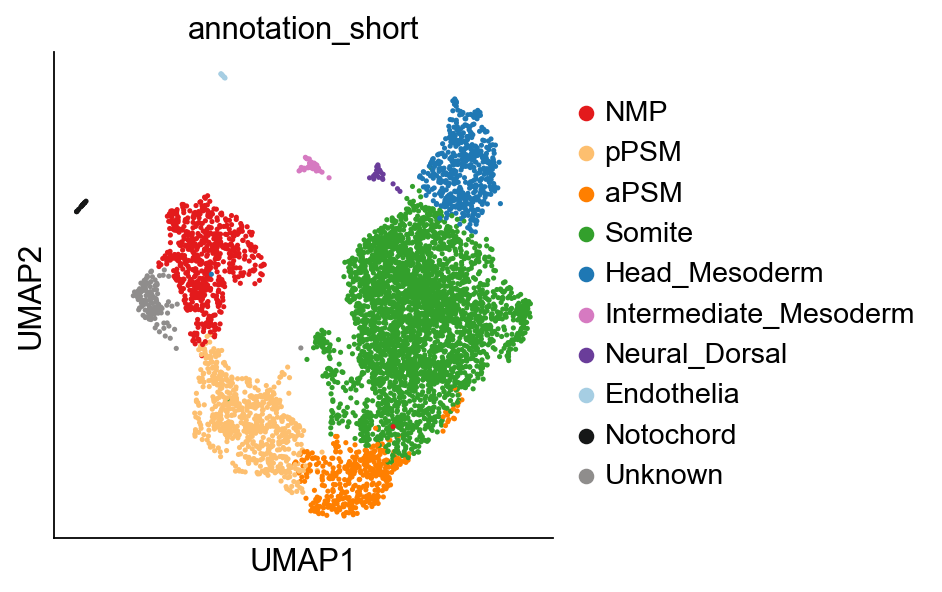

In [6]:
WT_adata_fused= WT_adata.copy()

WT_adata_fused.obs['annotation_short'] = (
    WT_adata_fused.obs["annotation"]
    .map(lambda x: {"Somite_1": "Somite", "Somite_2": "Somite", "Somite_3": "Somite"}.get(x, x))
    .astype("category")
)

WT_adata_fused.obs['annotation_short'] = WT_adata_fused.obs['annotation_short'].cat.reorder_categories(['NMP','pPSM','aPSM','Somite',
                     'Head_Mesoderm','Intermediate_Mesoderm','Neural_Dorsal','Endothelia','Notochord', 'Unknown' ])
custom_colors = [
    '#e31a1c', '#fdbf6f', '#ff7f00', '#33a02c',
    '#1f78b4', '#d67ac1', '#6a3d9a', 
    '#a6cee3', '#161717', '#8f8d8c'  
]

WT_adata_fused.uns["annotation_short_colors"] = custom_colors

sc.pl.umap(WT_adata_fused, color="annotation_short")

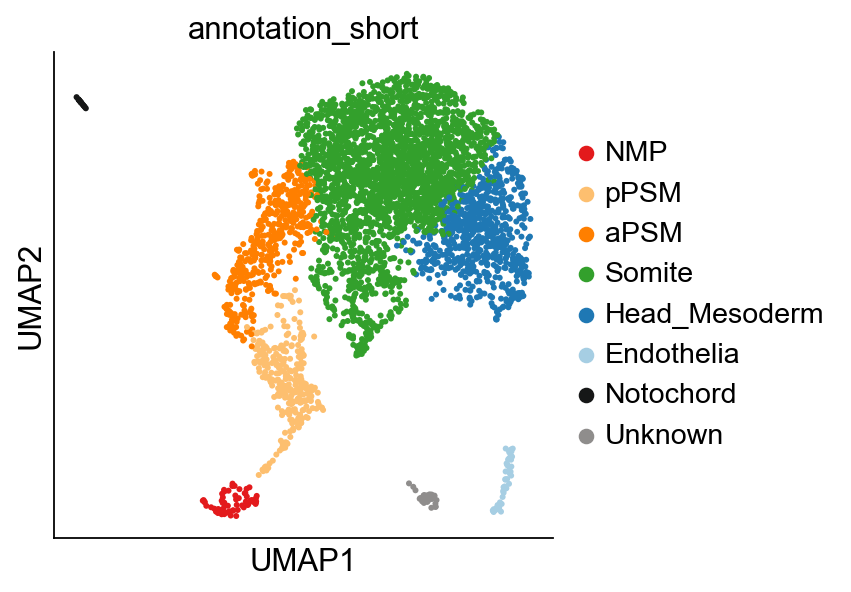

In [7]:
HOXKO_adata_fused= HOXKO_adata.copy()

HOXKO_adata_fused.obs['annotation_short'] = (
    HOXKO_adata_fused.obs["annotation"]
    .map(lambda x: {"Somite_1": "Somite", "Somite_2": "Somite"}.get(x, x))
    .astype("category")
)

HOXKO_adata_fused.obs['annotation_short'] = HOXKO_adata_fused.obs['annotation_short'].cat.reorder_categories(['NMP','pPSM','aPSM','Somite',
                     'Head_Mesoderm','Endothelia','Notochord', 'Unknown' ])

custom_colors2 = [
    '#e31a1c', '#fdbf6f', '#ff7f00',
    '#33a02c','#1f78b4', 
    '#a6cee3', '#161717', '#8f8d8c'  
]

HOXKO_adata_fused.uns["annotation_short_colors"] = custom_colors2
sc.pl.umap(HOXKO_adata_fused, color="annotation_short")

## Get the list of DEG and plot markers for WT sample

ranking genes
    finished: added to `.uns['wilcoxon_fused']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:27)


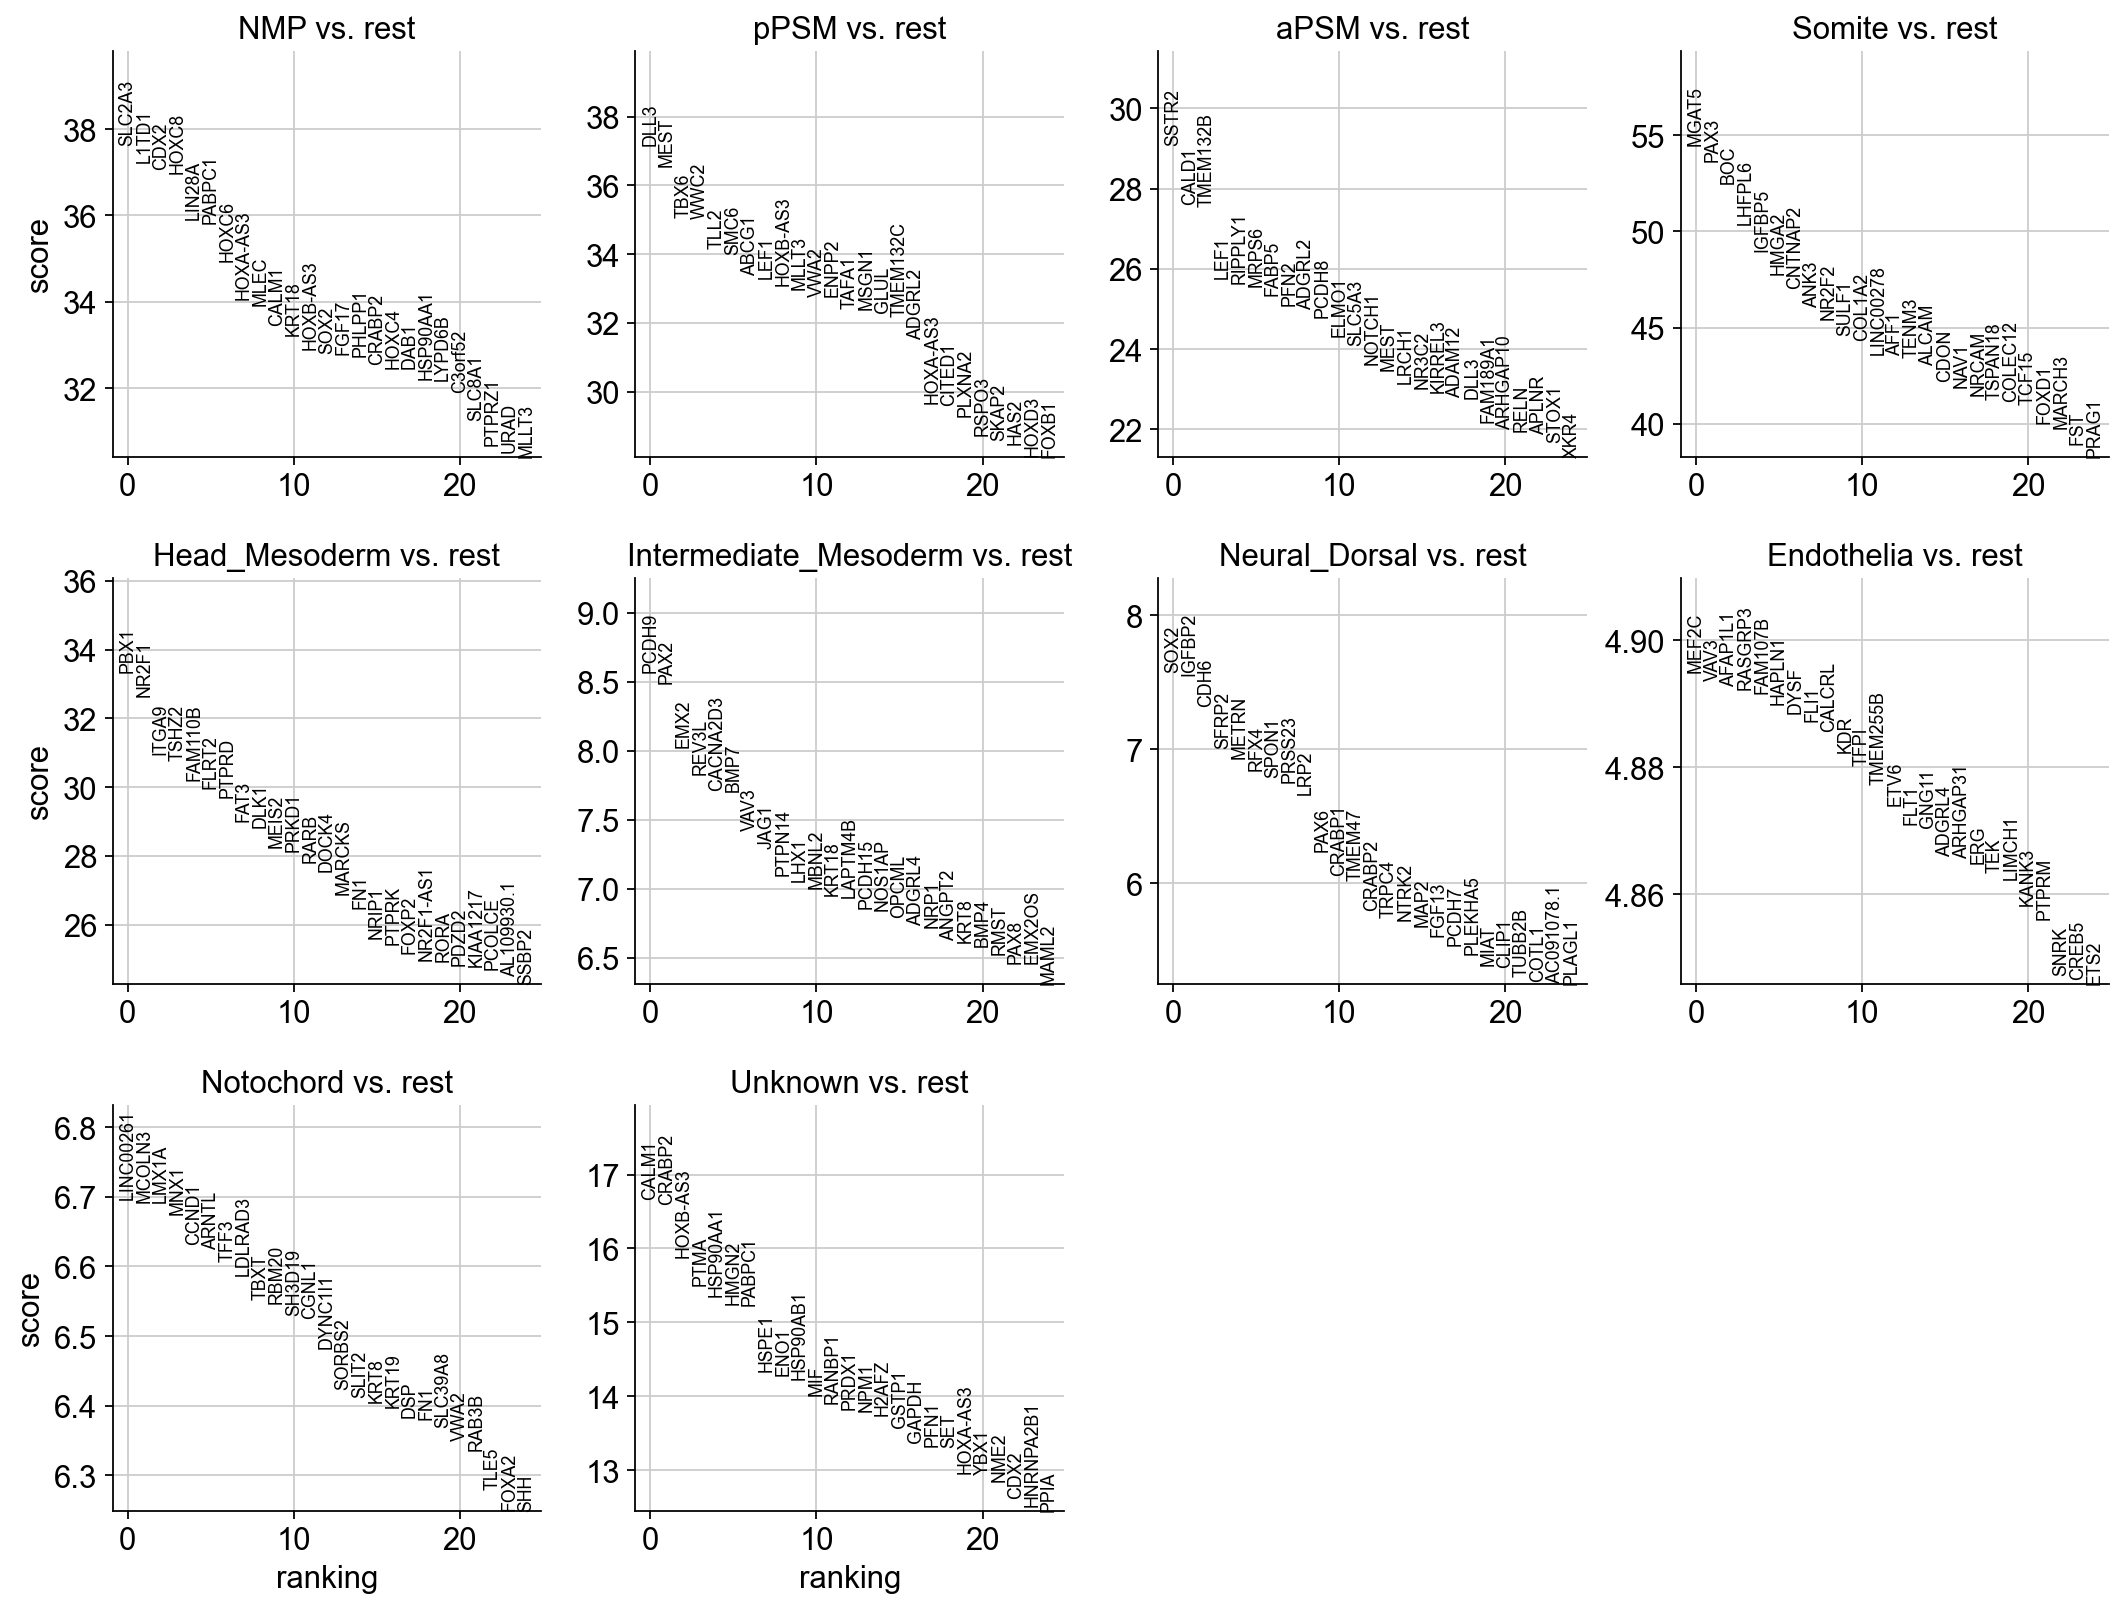

In [8]:
sc.tl.rank_genes_groups(WT_adata_fused, 'annotation_short', method='wilcoxon', key_added = "wilcoxon_fused")
sc.pl.rank_genes_groups(WT_adata_fused, n_genes=25, sharey=False, key="wilcoxon_fused")

In [9]:
result = WT_adata_fused.uns['wilcoxon_fused']
groups = result['names'].dtype.names  

dfs = []
for group in groups:
    df = sc.get.rank_genes_groups_df(WT_adata_fused, group=group, key='wilcoxon_fused')
    df['group'] = group
    dfs.append(df)

deg_df = pd.concat(dfs, axis=0)
deg_df.to_csv('20260831_WT_wilcoxon_DEG_Allclusters_Somitefused.csv', index=False)

Now we represent in a dotpot some marker genes identified in the list of DEG from Wilcoxon

In [10]:
genes  = ["NKX1-2","SOX2","CDX2","CDX4", "TBXT",  # NMP
          "TBX6","MSGN1","HES7","MESP1","MESP2","MEOX1","RIPPLY1",
          "FOXC2","ALDH1A2","MEOX2", 'PAX3','TCF15',"SIX1","EYA1","EYA2","FOXD1", "UNCX", "EPHB2", #Mesoderm
          "FOXA2", "NOTO","SHH",  #notochord
          "PAX6","MAP2", #dorsal neural
          "JAG1","PAX8","PAX2",  "GDNF", #nephric
          "TBX1","TWIST1", "TCF21", # anteriorParaxialMesoderm
          "KDR","SOX17", "CD34"  # endothelial
         ]

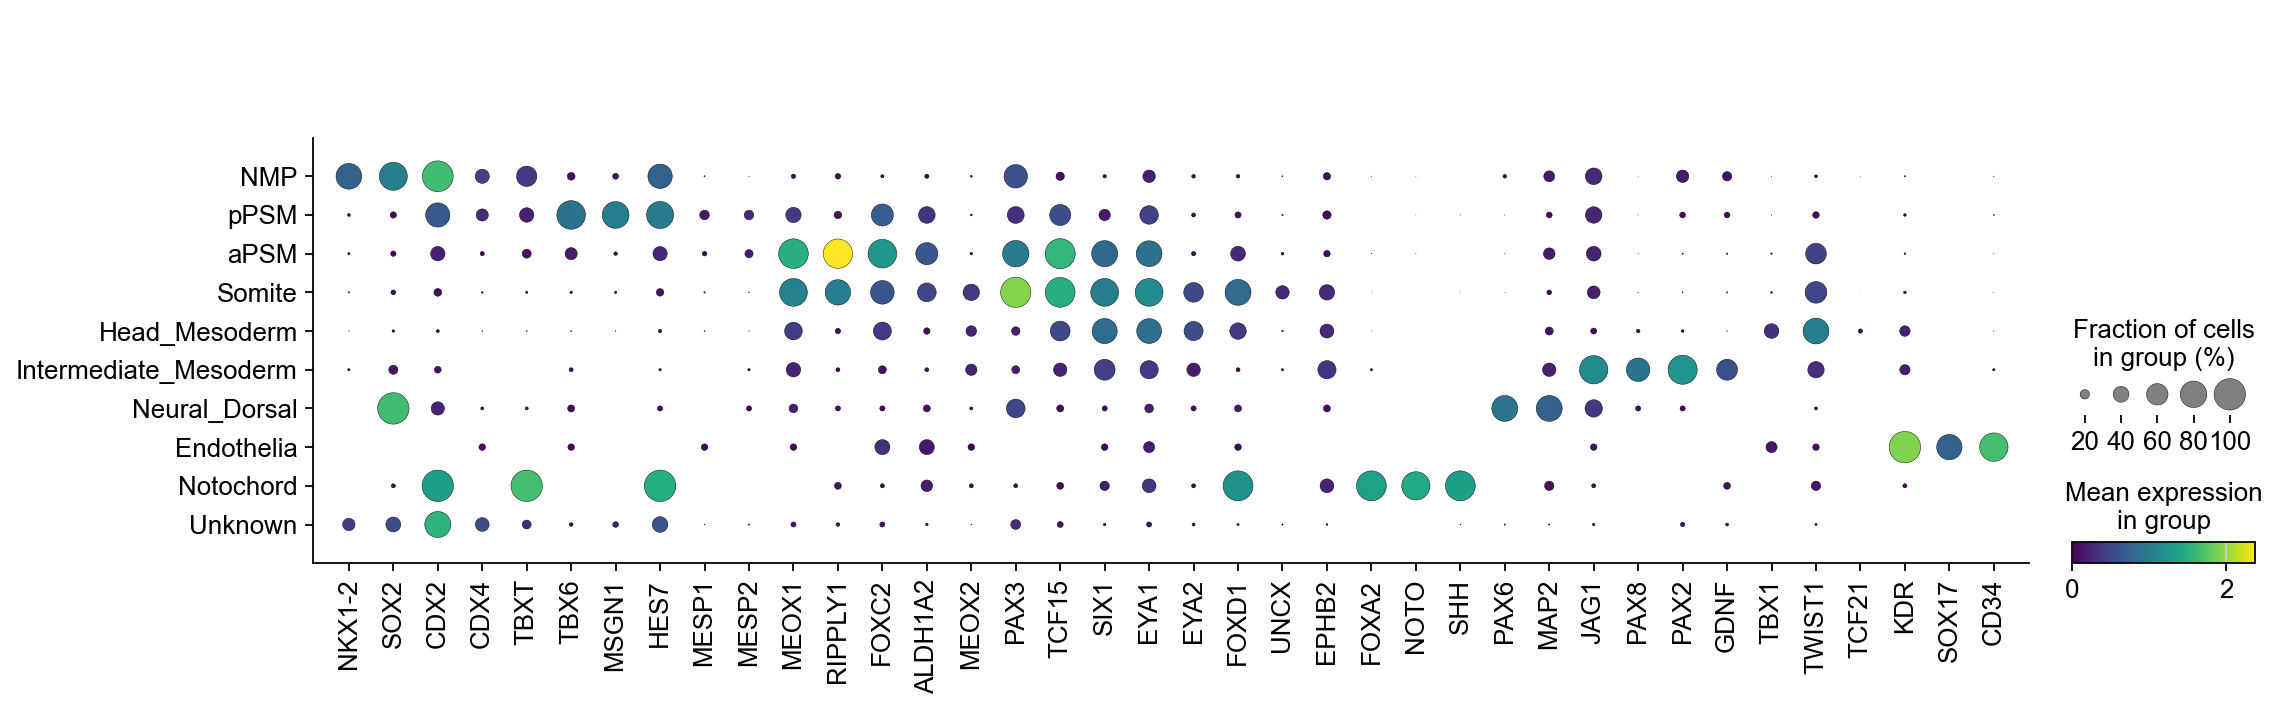

In [11]:
sc.pl.dotplot(WT_adata_fused, genes, color_map="viridis", groupby='annotation_short', save="20260831_WT_dotplot_Marker_genes_Somitefusedclusters.pdf")

In [12]:
hox_genes= ["HOXA1","HOXA2", "HOXA3", "HOXA4", "HOXA5","HOXA6","HOXA7","HOXA9","HOXA10","HOXA13", #'HOXA8', "HOXA11","HOXA12" not expressed
            "HOXB1","HOXB2", "HOXB3", "HOXB4", "HOXB5","HOXB6","HOXB7","HOXB8","HOXB9",  # "HOXB10","HOXB11","HOXB12","HOXB13" not expressed
            "HOXC4","HOXC5","HOXC6","HOXC8","HOXC9","HOXC10", # 'HOXC1','HOXC2', 'HOXC3',  'HOXC7', 'HOXC11', 'HOXC12', 'HOXC13' not expressed
            "HOXD1","HOXD3", "HOXD4","HOXD8", "HOXD9","HOXD13" # 'HOXD2', 'HOXD5', 'HOXD6', 'HOXD7', 'HOXD10', 'HOXD11', 'HOXD12', not expressed
           ]

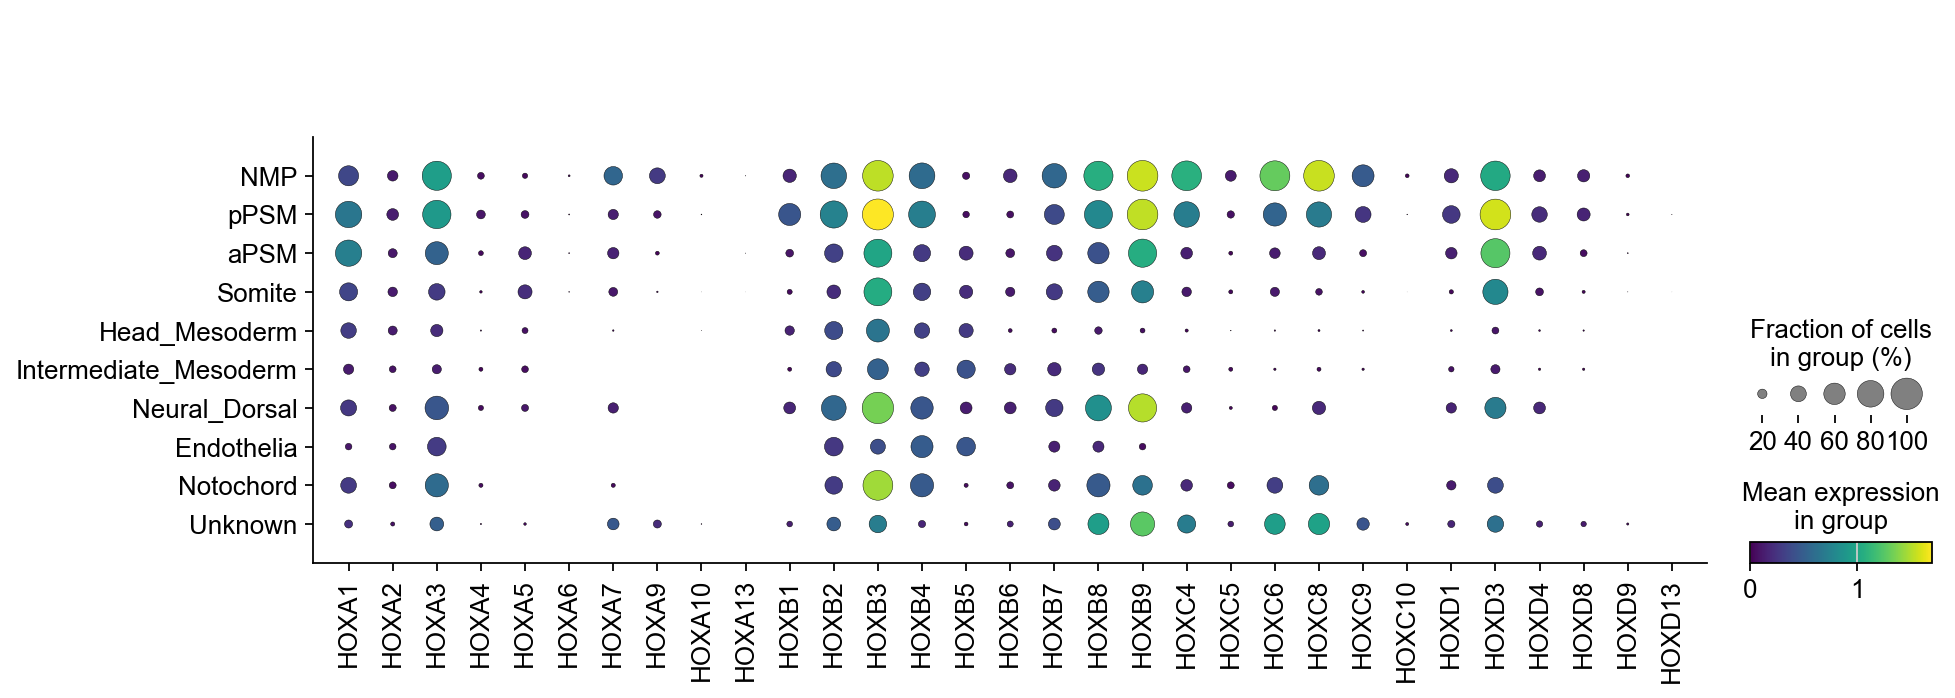

In [13]:
sc.pl.dotplot(WT_adata_fused, hox_genes, color_map="viridis", groupby='annotation_short', save="20260831_WT_dotplot_HOX_genes_Somitefusedclusters.pdf")

## Get the list of DEG and plot markers for HOXKO sample

ranking genes
    finished: added to `.uns['wilcoxon_fused']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:20)


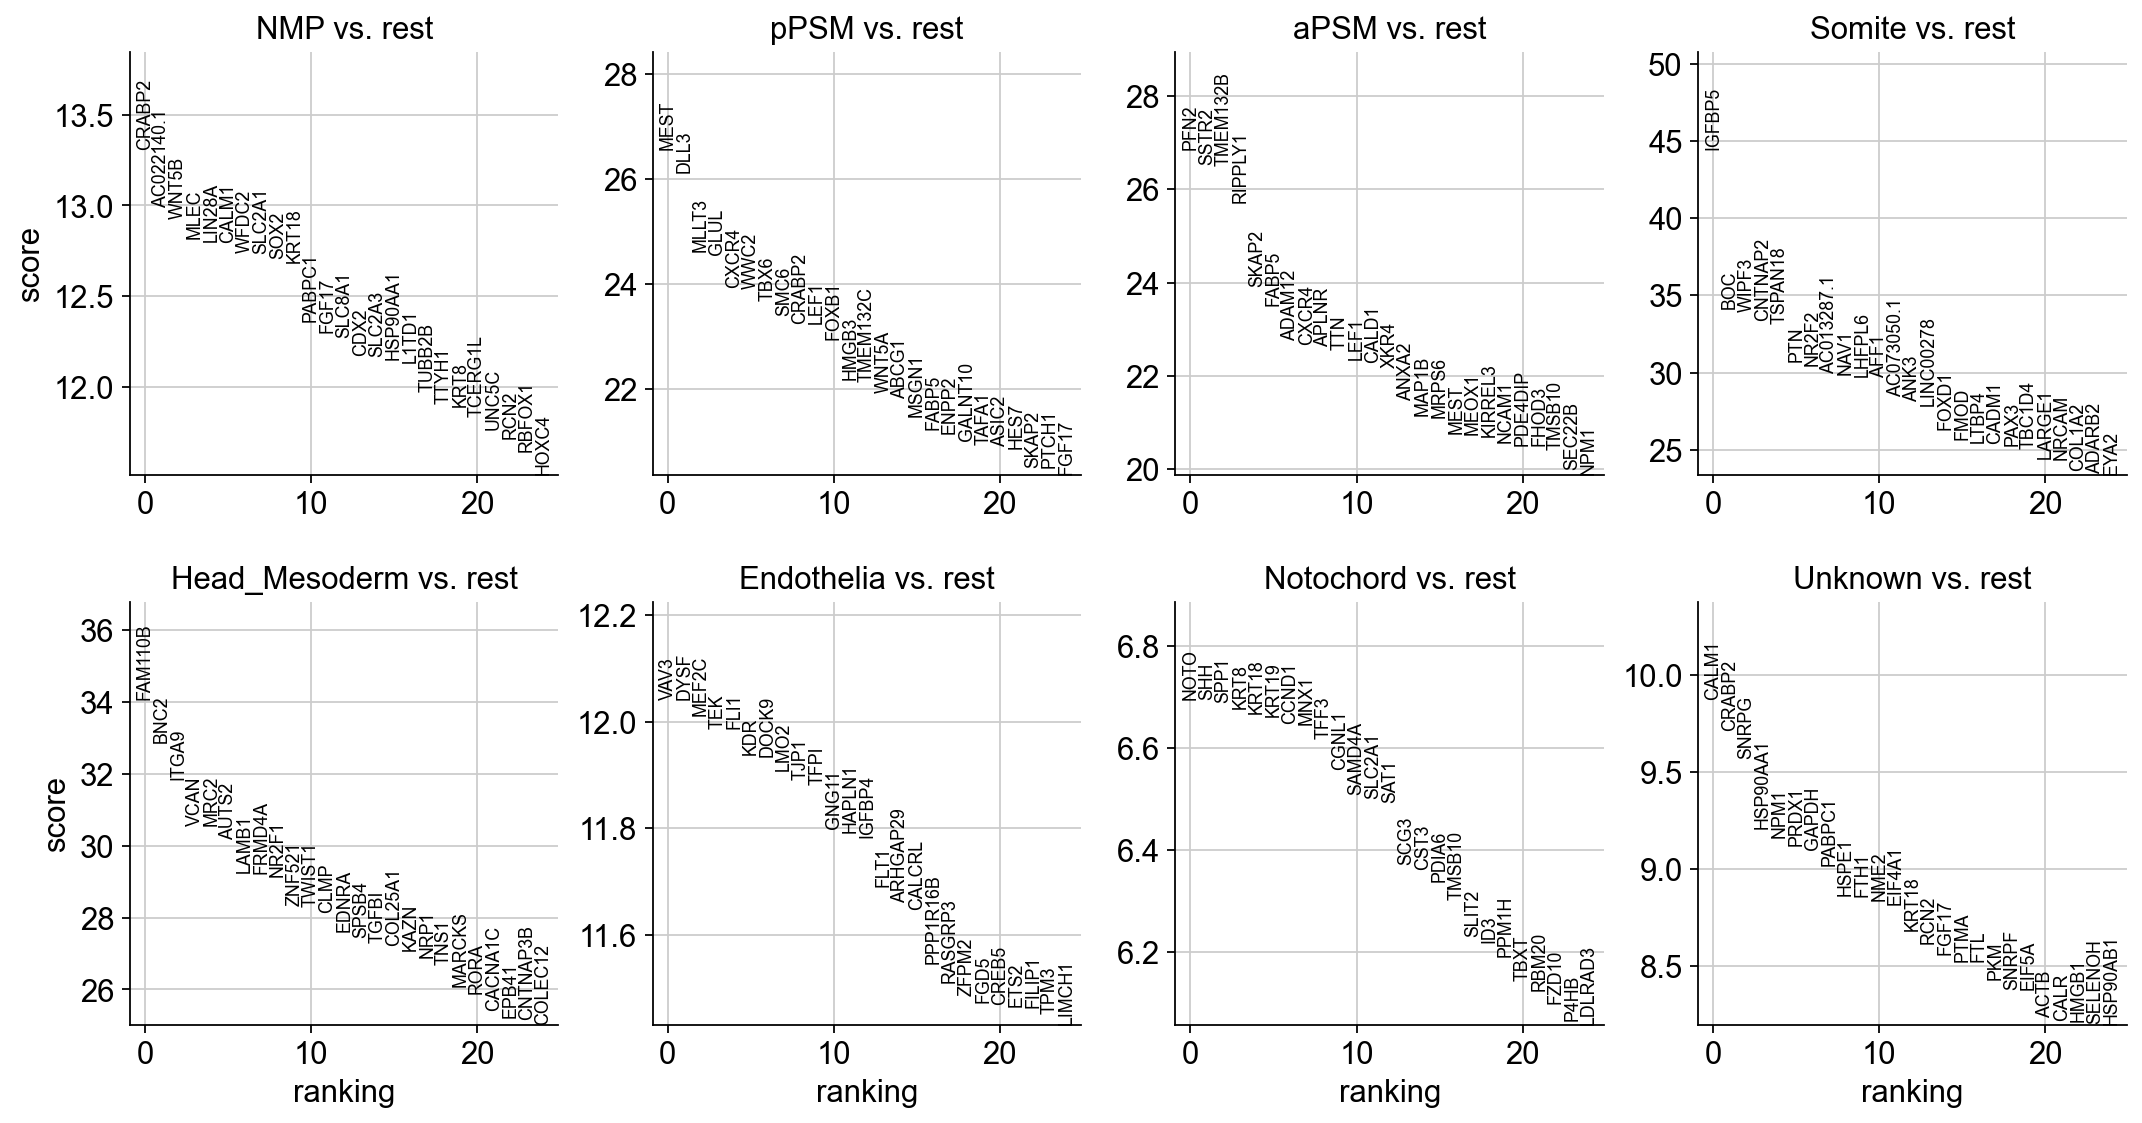

In [14]:
sc.tl.rank_genes_groups(HOXKO_adata_fused, 'annotation_short', method='wilcoxon', key_added = "wilcoxon_fused")
sc.pl.rank_genes_groups(HOXKO_adata_fused, n_genes=25, sharey=False, key="wilcoxon_fused")

In [15]:
result = HOXKO_adata_fused.uns['wilcoxon_fused']
groups = result['names'].dtype.names  

dfs = []
for group in groups:
    df = sc.get.rank_genes_groups_df(HOXKO_adata_fused, group=group, key='wilcoxon_fused')
    df['group'] = group
    dfs.append(df)

deg_df = pd.concat(dfs, axis=0)
deg_df.to_csv('20260831_HOXKO_wilcoxon_DEG_Allclusters_Somitefused.csv', index=False)

Same for HOXKO

In [16]:
genes2  = ["NKX1-2","SOX2","CDX2","CDX4", "TBXT",  # NMP
          "TBX6","MSGN1","HES7","MESP1","MESP2","MEOX1","RIPPLY1",
          "FOXC2","ALDH1A2","MEOX2",'PAX3','TCF15',"SIX1","EYA1","EYA2", "FOXD1", "UNCX", "EPHB2", #Mesoderm
          "FOXA2", "NOTO","SHH",  #notochord
          "TBX1","TWIST1", # anteriorParaxialMesoderm
          "KDR","SOX17", "CD34"  # endothelial
         ]

Some smaller clusters were missing in the HOXKO (Intermediate Meso and Dorsal Neural), could be smaller sampling. 

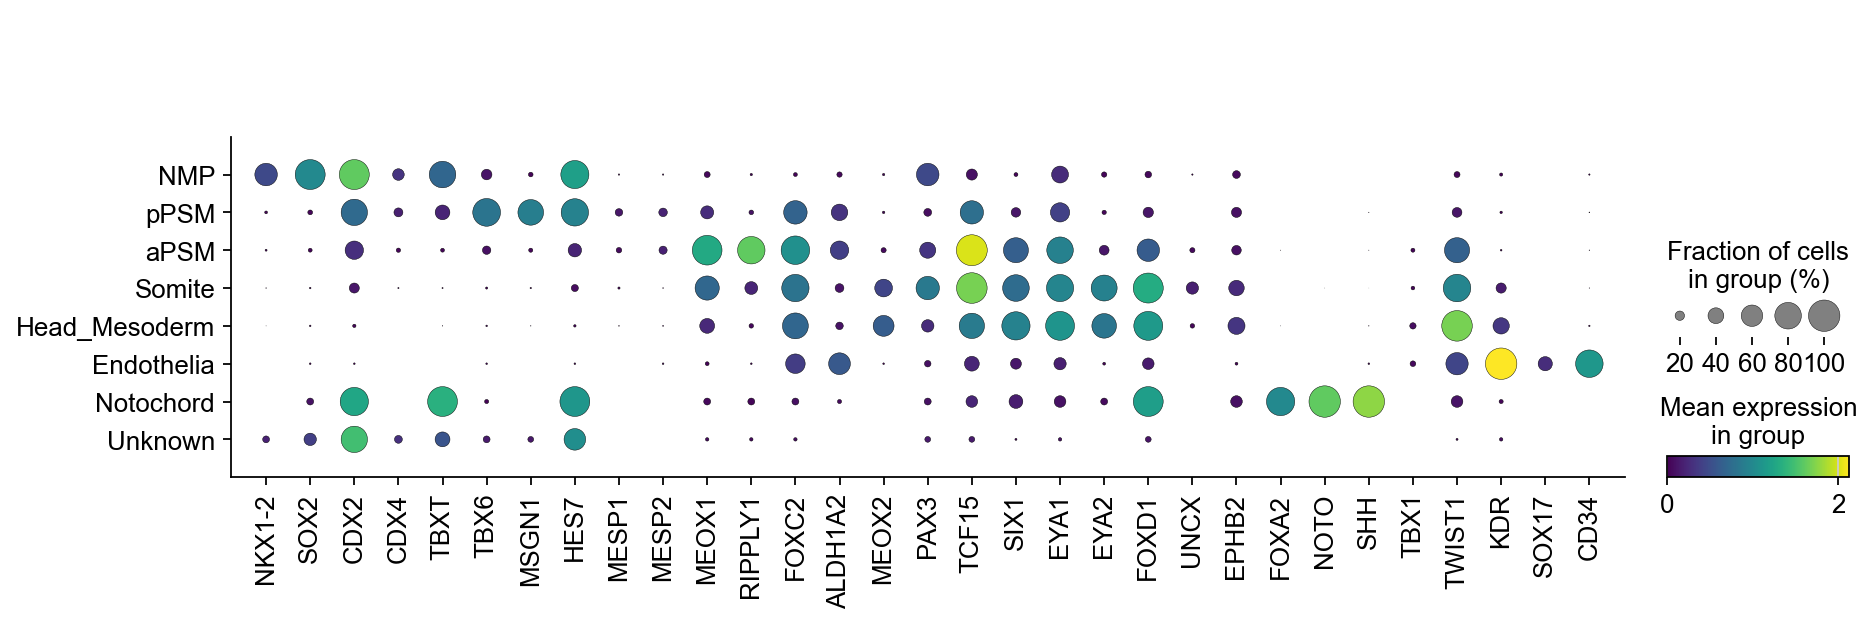

In [17]:
sc.pl.dotplot(HOXKO_adata_fused, genes2, color_map="viridis", groupby='annotation_short', save="20260831_HOXKO_dotplot_Marker_genes_Somitefusedclusters.pdf")

### Additional plots requested in the Integrated Dataset

In [18]:
adata_int = sc.read_h5ad("D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony_clustered_anno.h5ad")

In [19]:
# check that the matrix looks like normalized counts
print(adata_int.X[1:10,1:10])

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


In [20]:
print(adata_int.raw.X[1:10,1:10]) 

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


In [21]:
adata_int.obs['annotation_short'] = (
    adata_int.obs["annotation"]
    .map(lambda x: {"Somite_1": "Somite", "Somite_2": "Somite"}.get(x, x))
    .astype("category")
)

adata_int.obs['annotation_short'] = adata_int.obs['annotation_short'].cat.reorder_categories(['NMP','pPSM','aPSM','Somite',
                     'Head_Mesoderm','Intermediate_Mesoderm','Neural_Dorsal','Endothelia','Notochord', 'Unknown_1','Unknown_2' ])

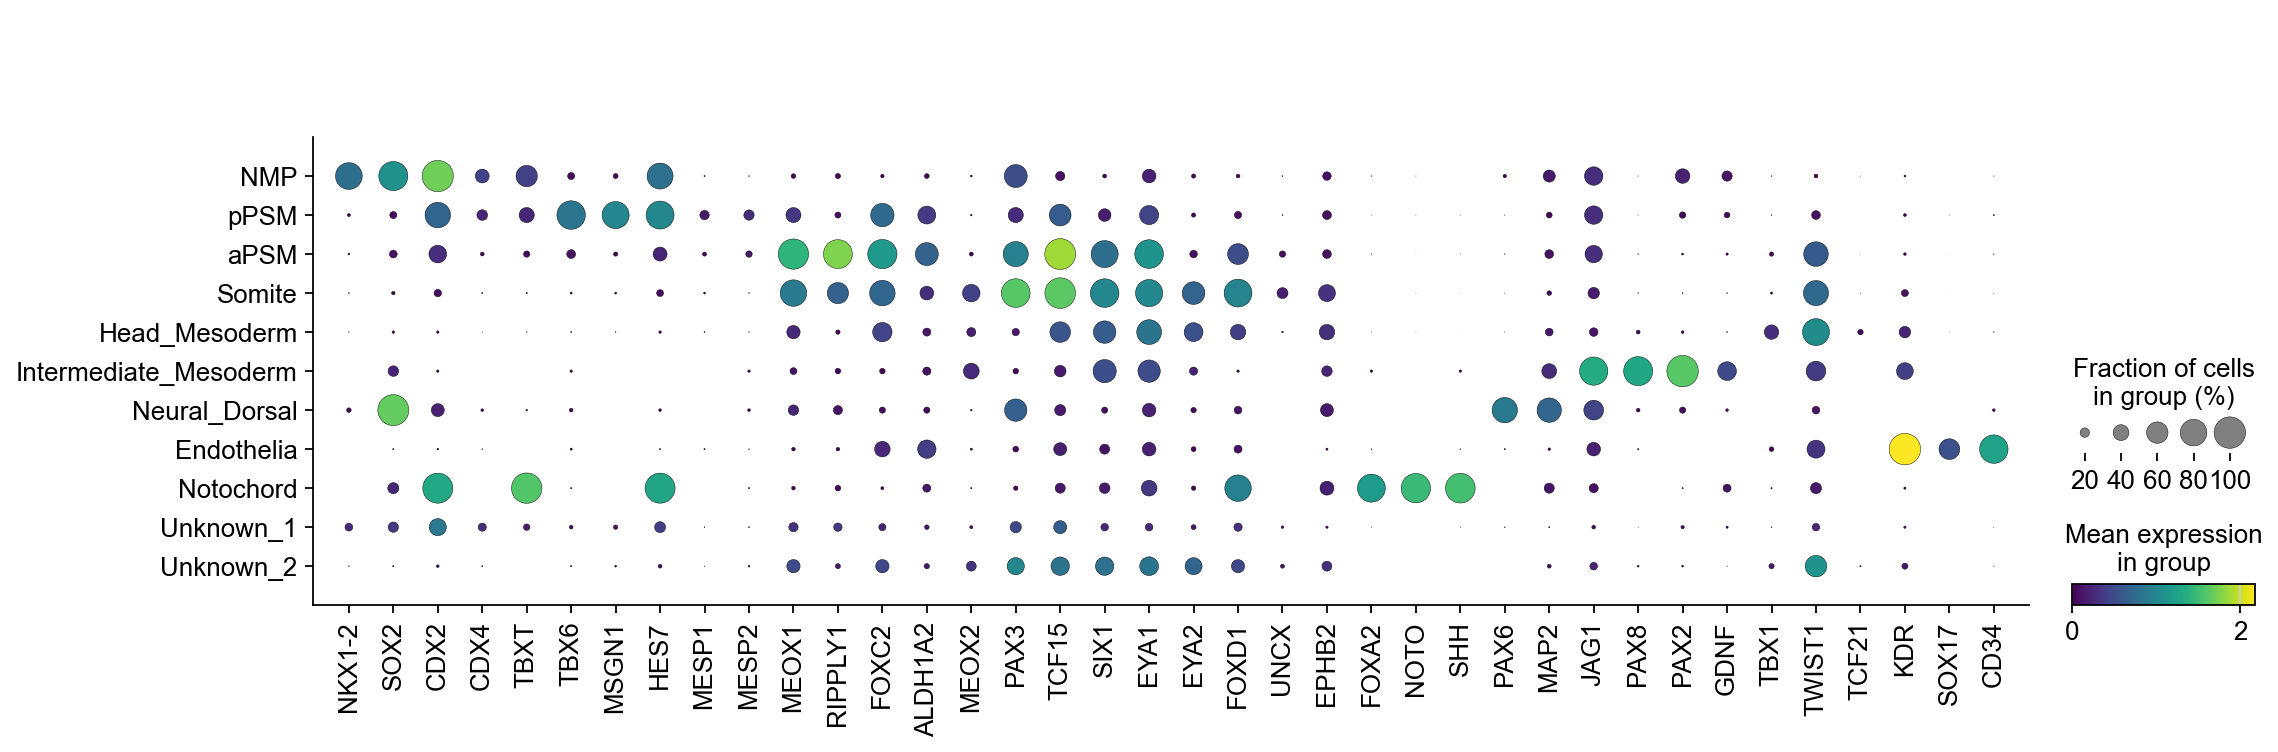

In [22]:
sc.pl.dotplot(adata_int, genes, color_map="viridis", groupby='annotation_short', save="20260831_HOXsamples_Integrated_dotplot_Marker_genesWithaddedGenes_Somitefusedclusters.pdf")

WT


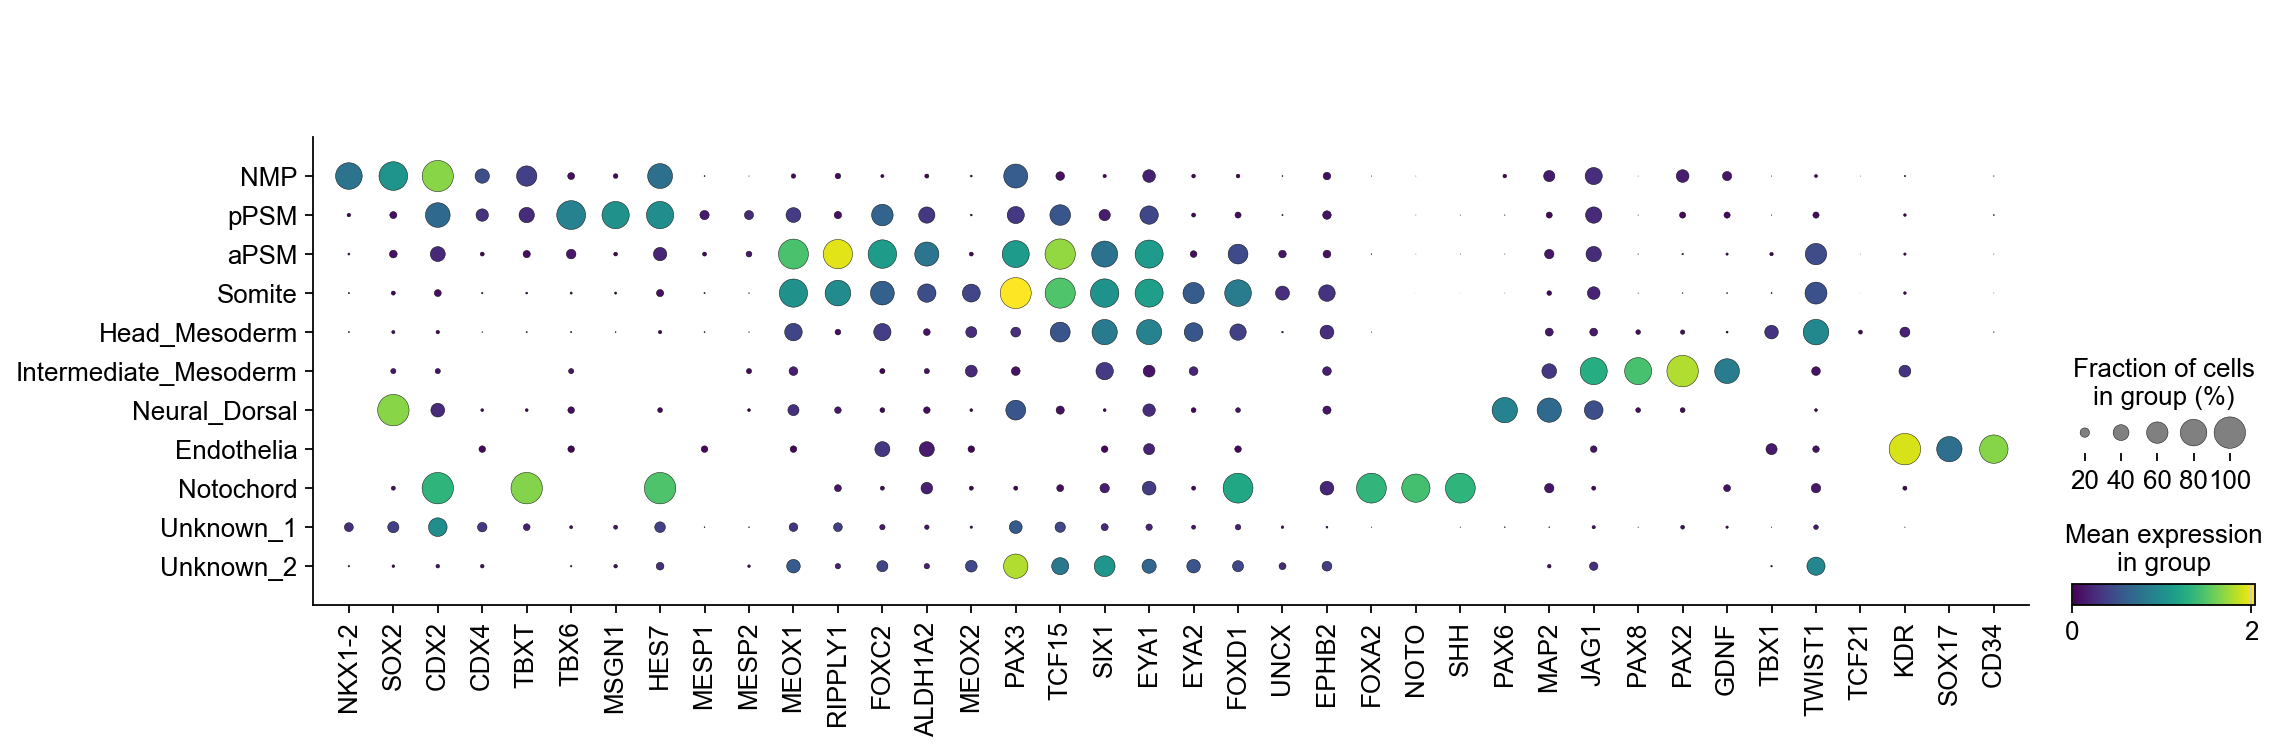

HOXD_KO


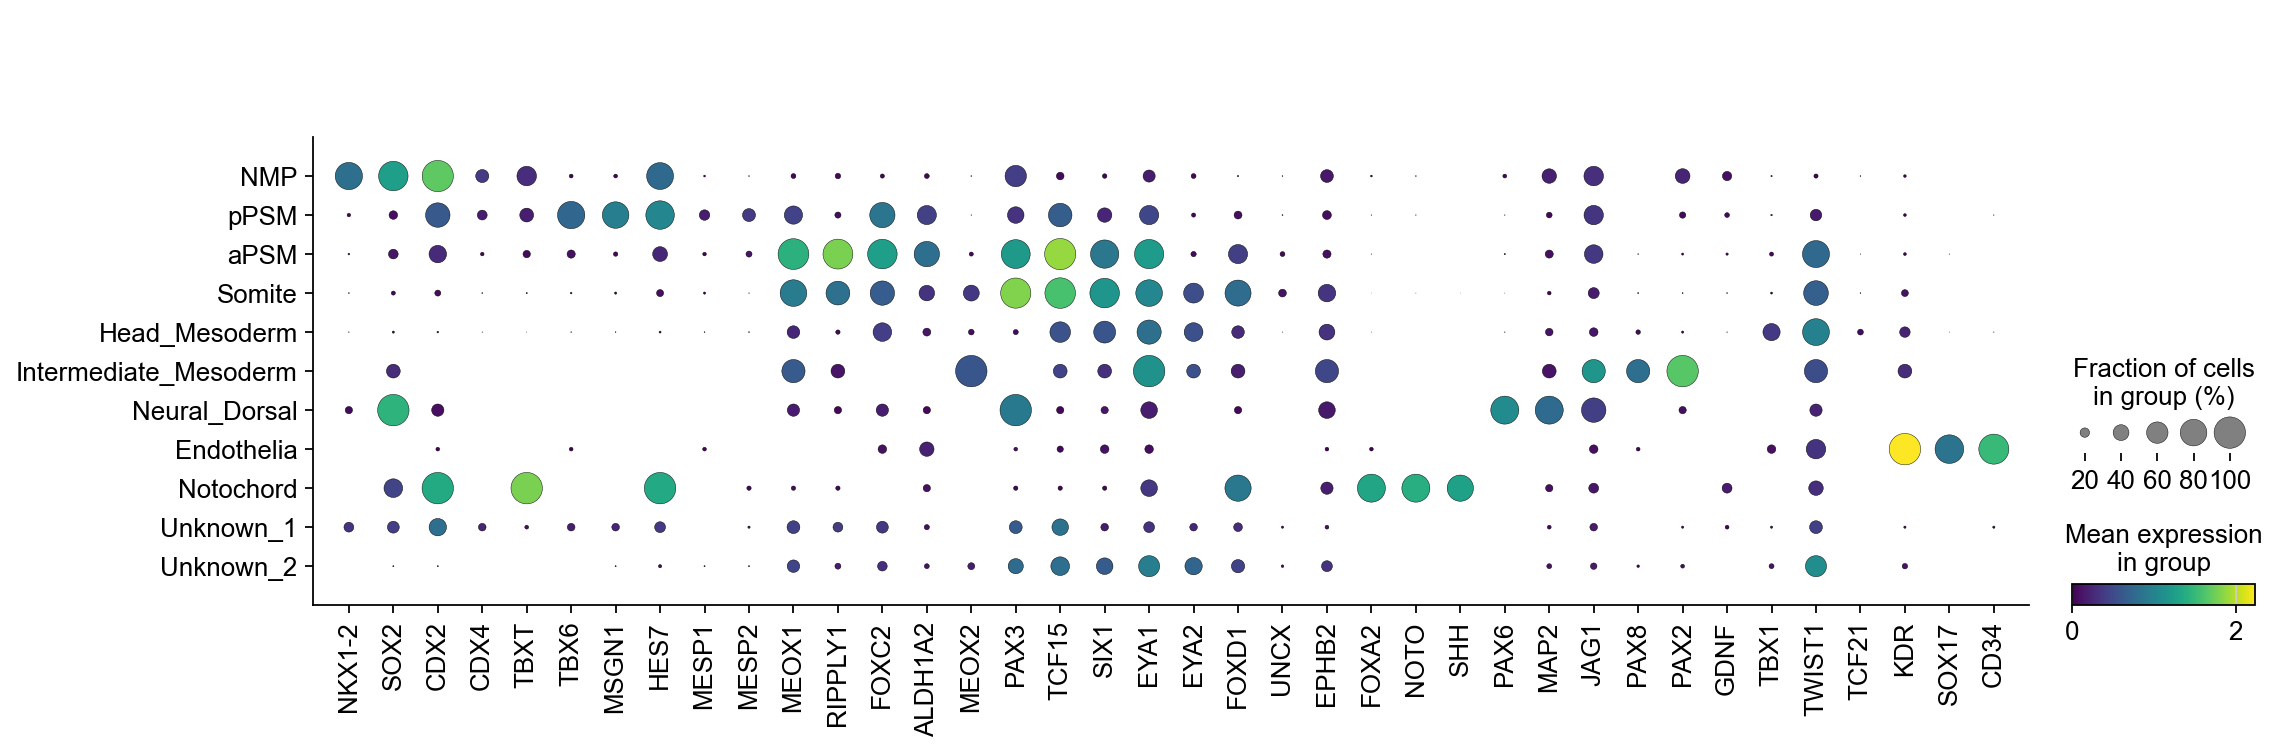

HOXBCD_KO


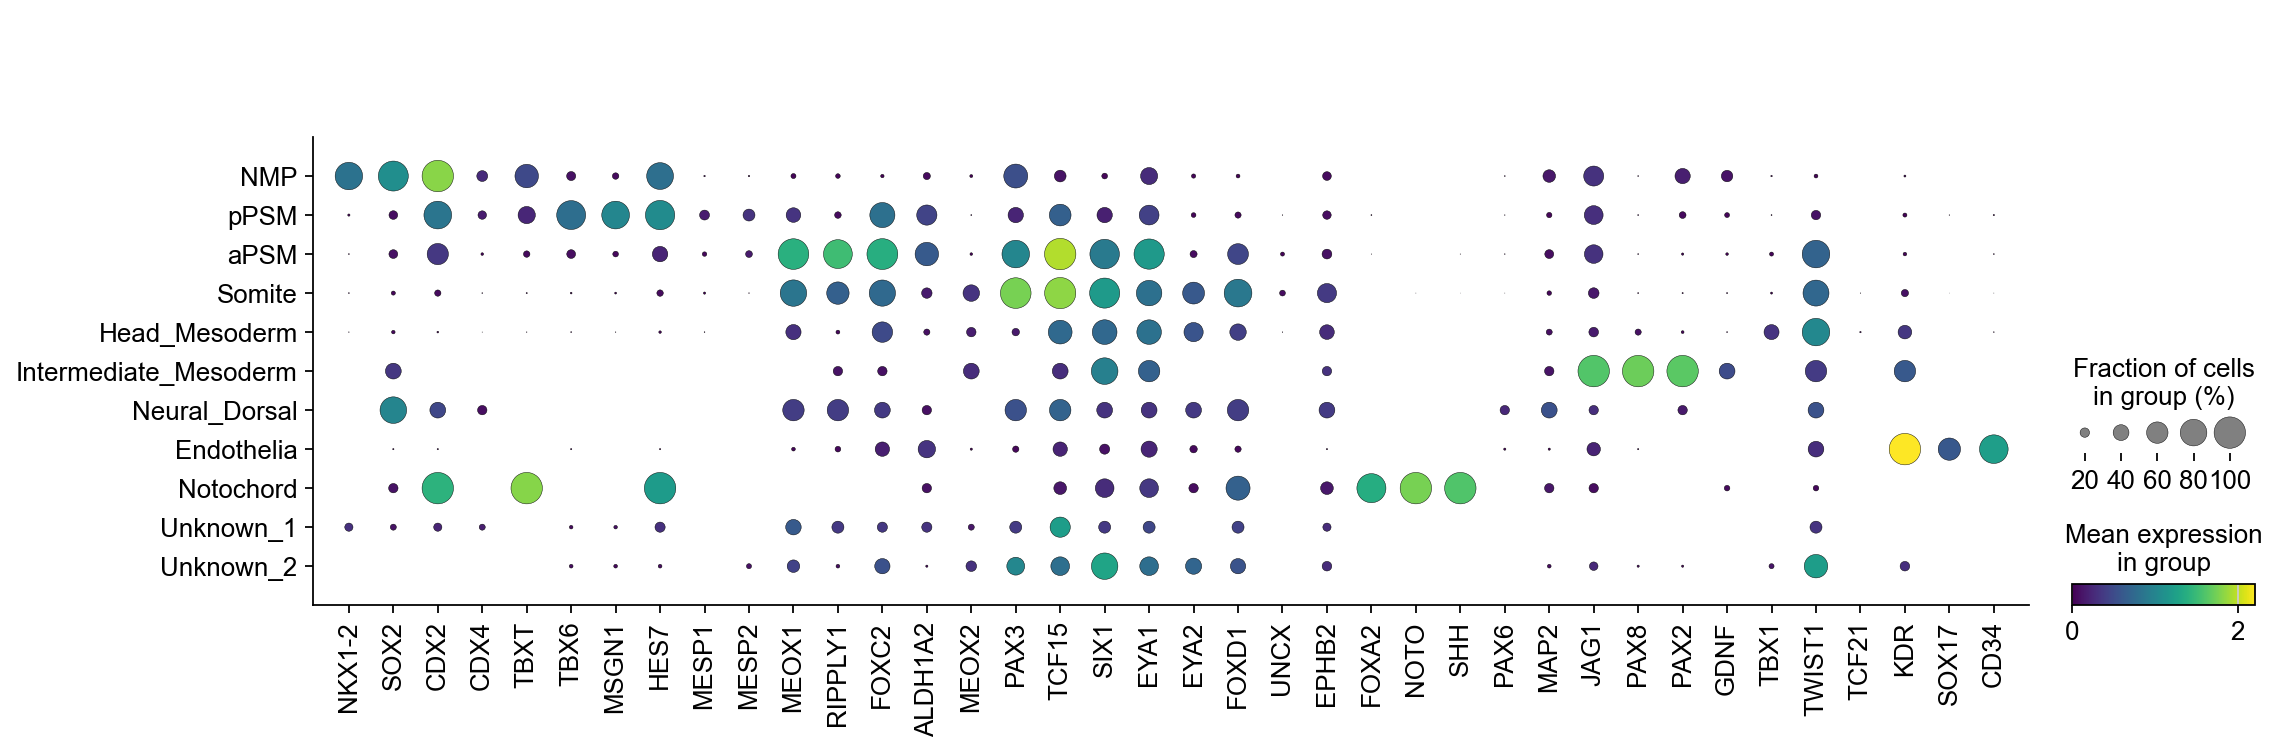

HOXCD_KO


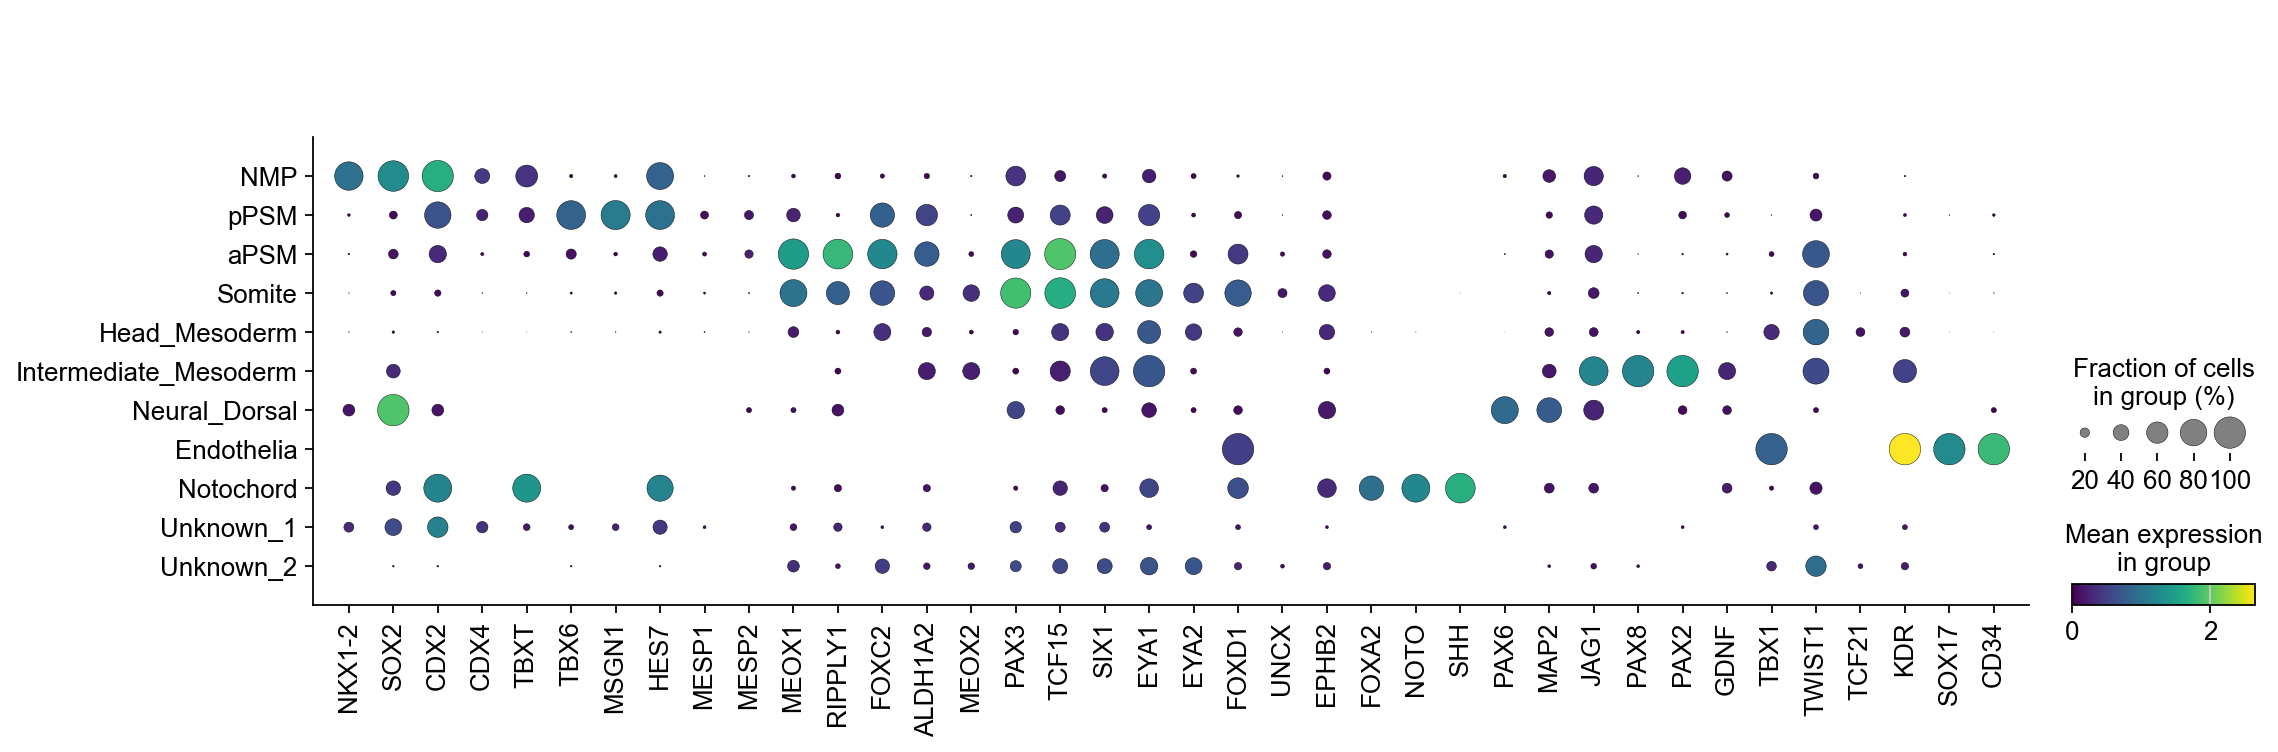

HOX_KO


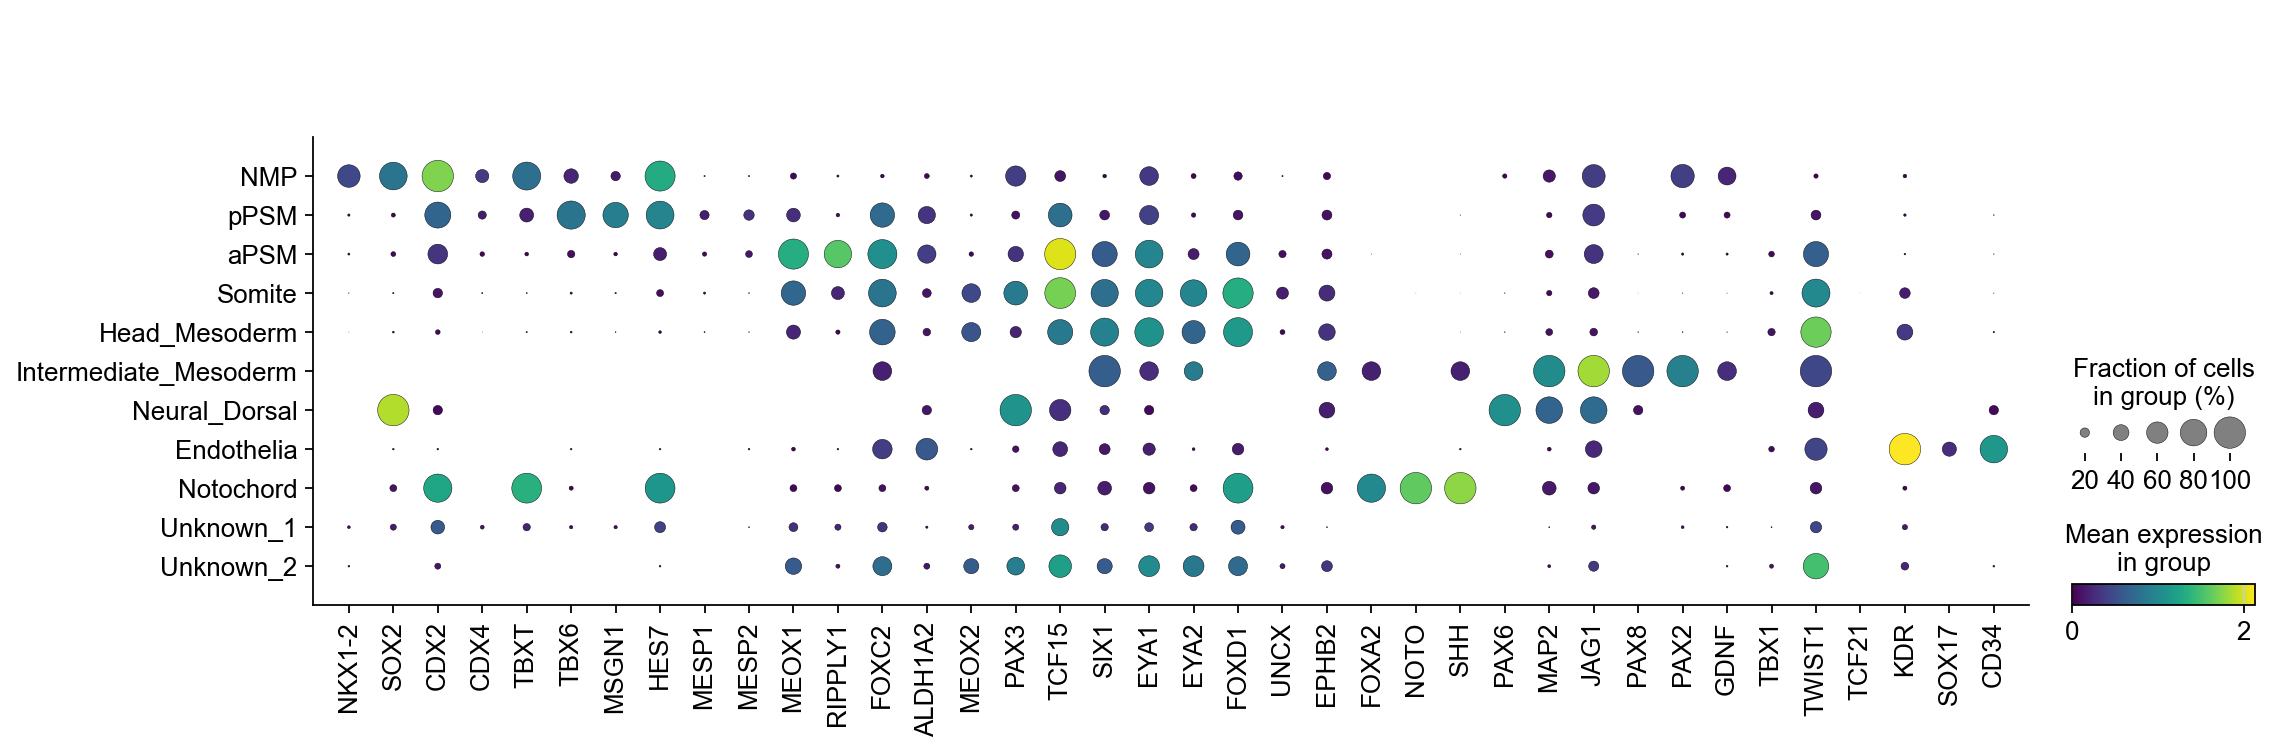

In [23]:
# Loop through each sample and plot a dot plot for the gene cluster
for i in ['WT', 'HOXD_KO', 'HOXBCD_KO', 'HOXCD_KO', 'HOX_KO']:
    print(i)
    sc.pl.dotplot(
        adata_int[adata_int.obs["sample"] == i],  
        var_names= genes,           
        groupby="annotation_short",            
        color_map="viridis",             
        save=f'20260831_HOXsamples_Integrated_dotplot_Marker_genesWithaddedGenes_{i}_Somitefusedclusters.pdf'
    )